# CVE Risk Classification — 02: EDA & Baseline (Naive Bayes)
**Imperial Business School Capstone | MSc Cybersecurity + AI/ML**

**Purpose:** Exploratory data analysis and Naive Bayes baseline.  
**Conclusion:** Naive Bayes **rejected** as final model — documented here as
methodological evidence of the research process.

> *'It was useful for exploratory purposes but doesn't serve as a model
> because it lacks accuracy and doesn't generalise.'*  
> — Author's research notes

**Why NB fails on CVE data:**
1. CVE descriptions have strong word co-dependencies (`buffer` + `overflow` +
   `kernel` together signal something very different than each word alone)
2. Class imbalance causes NB to gravitate toward the majority class
3. Boolean word presence loses all positional and contextual meaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re, warnings
warnings.filterwarnings('ignore')

# ── Load clean data from notebook 01 ─────────────────────────────────────────
df = pd.read_csv('data/df_clean.csv')
print(f'Loaded df_clean: {df.shape}')

Loaded df_clean: (155852, 22)


## 1. Exploratory Data Analysis

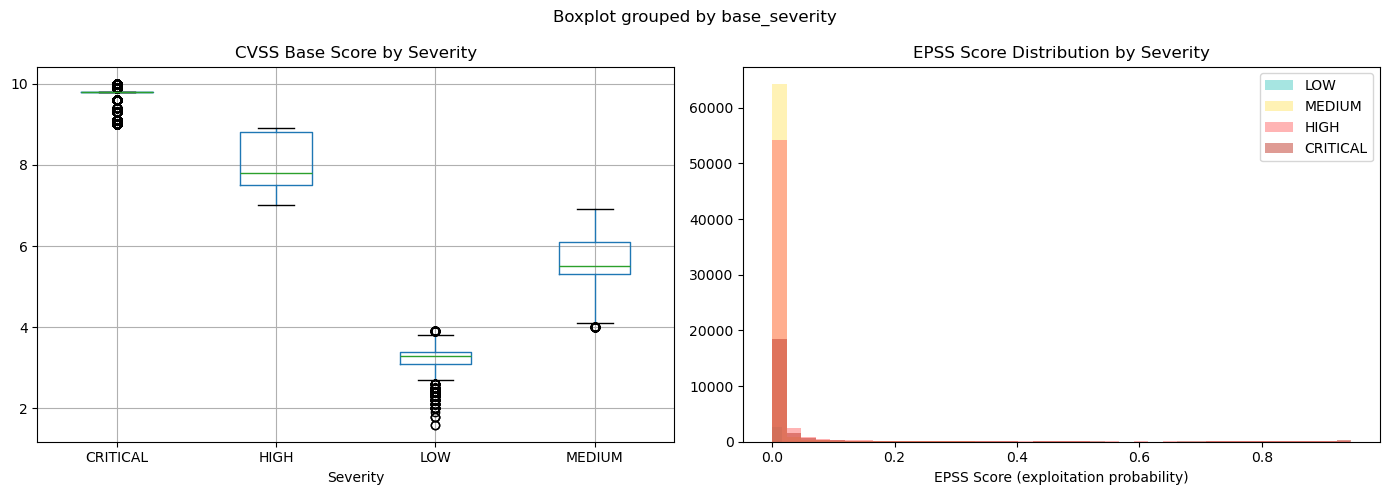

In [2]:
# ── CVSS score distribution by severity
if 'base_score' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
    palette = {'LOW':'#4ECDC4','MEDIUM':'#FFE66D','HIGH':'#FF6B6B','CRITICAL':'#C0392B'}

    # Box plot
    df_plot = df[df['base_severity'].isin(order)]
    df_plot.boxplot(column='base_score', by='base_severity', ax=axes[0])
    axes[0].set_title('CVSS Base Score by Severity')
    axes[0].set_xlabel('Severity')

    # EPSS distribution
    if 'epss_score' in df.columns:
        for sev in order:
            sub = df[df['base_severity'] == sev]['epss_score'].dropna()
            axes[1].hist(sub, bins=40, alpha=0.5, label=sev, color=palette[sev])
        axes[1].set_title('EPSS Score Distribution by Severity')
        axes[1].set_xlabel('EPSS Score (exploitation probability)')
        axes[1].legend()

    plt.tight_layout()
    plt.savefig('outputs/02_eda_distributions.png', dpi=150)
    plt.show()

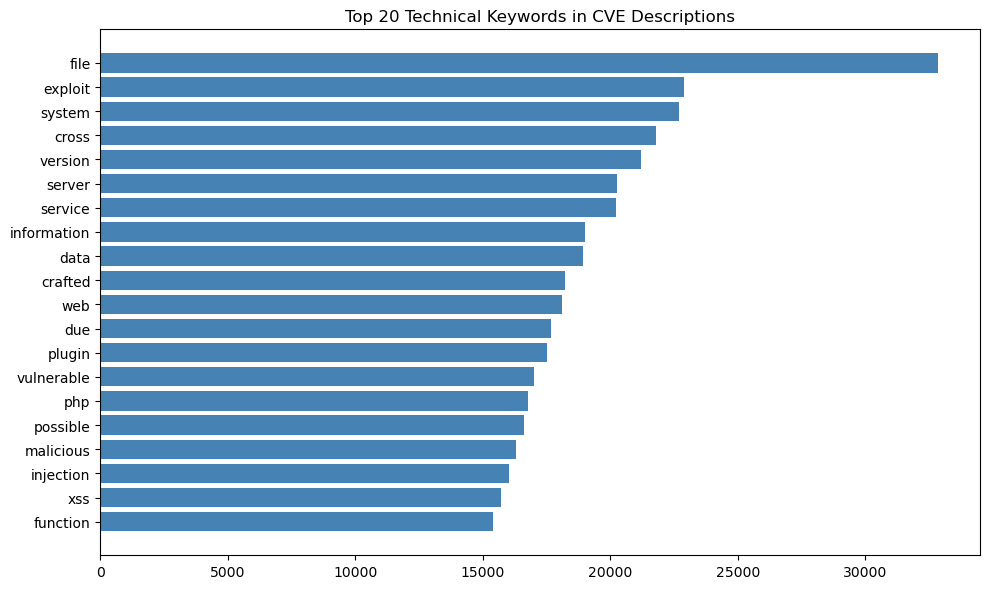

In [3]:
# ── Top CVE keywords (filtered)
cyber_noise = {
    'this','vulnerability','attacker','allows','versions','issue','can',
    'before','could','via','code','has','access','from','arbitrary',
    'remote','been','may','affected','site','are','through','candidate',
    'reason','all','attackers','prior','which','none','when','into',
    'used','user','was','not','allow','execute','scripting','execution',
    'the','and','a','in','to','of','for','with','on','is','an','that','by'
}

def get_tech_keywords(text):
    if pd.isna(text): return []
    text = re.sub(r'[^\w\s]', ' ', str(text).lower())
    return [w for w in text.split() if w not in cyber_noise and len(w) > 2]

all_words = []
df['description_data'].dropna().apply(lambda x: all_words.extend(get_tech_keywords(x)))
word_counts = Counter(all_words)

top_words = pd.DataFrame(word_counts.most_common(20), columns=['word','count'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_words['word'], top_words['count'], color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 20 Technical Keywords in CVE Descriptions')
plt.tight_layout()
plt.savefig('outputs/02_top_keywords.png', dpi=150)
plt.show()

## 2. Naive Bayes Baseline (Documented — Rejected)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ── Feature: TF-IDF on description (top 500 terms — capped to avoid overfitting)
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X_text = tfidf.fit_transform(df['description_data'].fillna(''))

le = LabelEncoder()
y  = le.fit_transform(df['base_severity'])

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

print('=== NAIVE BAYES BASELINE (REJECTED) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))
print()
print('VERDICT: Low recall on CRITICAL and LOW classes confirms class-imbalance')
print('sensitivity and failure to capture word co-dependencies.')
print('→ Proceeding to Hybrid KNN + Decision Tree in notebook 03.')

=== NAIVE BAYES BASELINE (REJECTED) ===
Accuracy: 0.6030

              precision    recall  f1-score   support

    CRITICAL       0.50      0.30      0.38      4831
        HIGH       0.55      0.71      0.62     12336
         LOW       0.17      0.00      0.00       549
      MEDIUM       0.70      0.64      0.67     13455

    accuracy                           0.60     31171
   macro avg       0.48      0.41      0.42     31171
weighted avg       0.60      0.60      0.59     31171


VERDICT: Low recall on CRITICAL and LOW classes confirms class-imbalance
sensitivity and failure to capture word co-dependencies.
→ Proceeding to Hybrid KNN + Decision Tree in notebook 03.
